# Week1_315832001

In [1]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
import cv2

from Codes.Quiz1 import *
from Codes.Quiz2 import *
from Codes.Quiz3 import *
from Codes.Quiz4 import *

# 影像路徑
image_path = "Data"

---
## Quiz 1 灰階影像

### 基礎
將 RGB 彩色影像轉換為灰階影像  
用與opencv相同的 BT.601 灰階加權公式：
$grayscale = 0.299R + 0.587G + 0.114B$

#### 流程
`numpy_rgb_to_gray()`：採用與 OpenCV 相同的 ITU-R BT.601 加權公式
```
Gray = 0.299 * R + 0.587 * G + 0.114 * B
```
由於 OpenCV 讀取影像時採用 **BGR** 順序，因此程式中先分別取得 B、G、R 三個通道，再對每個像素做加權平均，並四捨五入後裁切至 0~255。

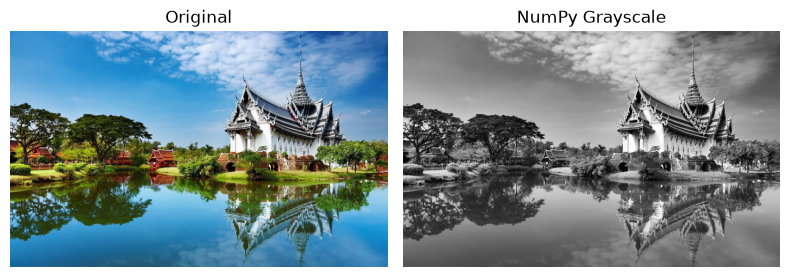

In [2]:
%matplotlib inline

img = cv2.imread("Data/Quiz1.jpg")
# numpy 灰階轉換
gray = numpy_rgb_to_gray(img)

# 對照圖
show_images(img, gray)

### 進階
使用 NumPy 自行實作灰階轉換演算法，並與 OpenCV 提供的方法  
重複執行 N = 50 次並取平均值，比較（1）執行速度、（2）轉換結果、（３）兩種方法之間的差異

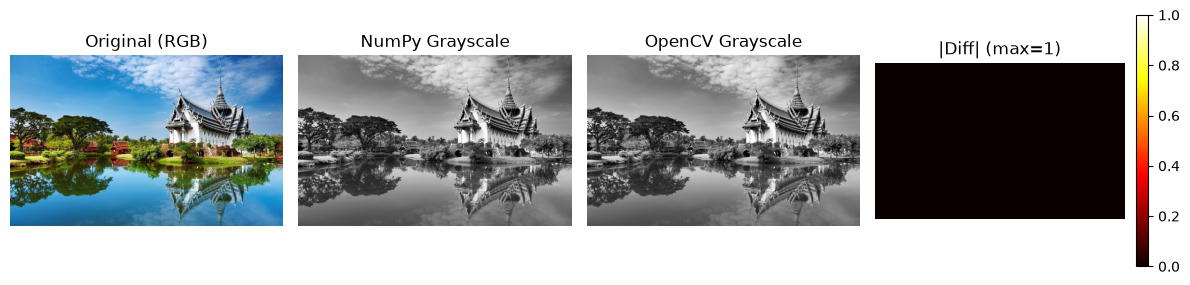

Quiz1 - RGB to Grayscale (Data/Quiz1.jpg)
重複執行次數 N = 50
[執行速度]
  NumPy  平均執行: 34.2566 ms
  OpenCV 平均執行: 0.7752 ms
  速度比 (NumPy / OpenCV): 44.19x
[轉換結果]
  NumPy  結果 - mean=120.71, std=53.13
  OpenCV 結果 - mean=120.71, std=53.13
[兩方法差異]
  不同像素數:總像素數 : 16/1600000
  比例               : 0.001000%
  最大像素差異        : 1
  平均像素差異       : 0.000010
  誤差 <=1 比例      :100.00%
輸出圖檔: Data/Quiz1_result\Quiz1_result.png



In [3]:
# 重複執行次數
N = 50

quiz1_result = run_quiz1(
        f"{image_path}/Quiz1.jpg",
        f"{image_path}/Quiz1_result",
        N
    )
print()

### Quiz1 小節
1. **執行速度**：  
OpenCV 轉換效率高約 40～50 倍。原因是 `cvtColor()` 底層由 C/C++ 實作並經過向量化/SIMD 優化，NumPy 版本雖然也是向量化運算，但仍需建立多個中介浮點陣列，Python 層呼叫開銷與記憶體配置成本使其明顯較慢。

2. **轉換結果**：  
兩者 mean、std 近乎相同。這是因為 NumPy 版本刻意採用與 OpenCV 相同的 BT.601 加權係數 `0.299R + 0.587G + 0.114B`，理論上兩者應完全一致；實測結果驗證了公式實作正確。

3. **兩方法差異**：  
最大像素差異為 1，比例極低（約 0.001%）。來自數值運算精度與取整方式不同——OpenCV 內部可能採用不同的四捨五入規則，NumPy 版本以浮點數運算後才轉型為 `uint8`，在小數點捨去的邊界情況下可能產生 1 個灰階值的偏差，屬於正常且可預期的浮點誤差範圍。

---
## Quiz2
### 基礎  
- 使用 Histogram Equalization 提升影像的明暗對比與動態範圍，  
- 繪製影像在 Histogram Equalization 處理前後的灰階 Histogram，觀察並比較亮度分布的差異。

#### 流程

`numpy_histogram_equalization()`：
1. 灰階影像
2. 計算灰階直方圖（0~255）
3. 計算 Cumulative Distribution Function (CDF)
4. 依公式 $s_k = round(\frac{CDF(r_k) - CDF_{min}}{(M \times N) - CDF_{min}} \times (L - 1))$ 正規化
5. 用查表 (LUT) 方式將每個像素映射到新的灰階值

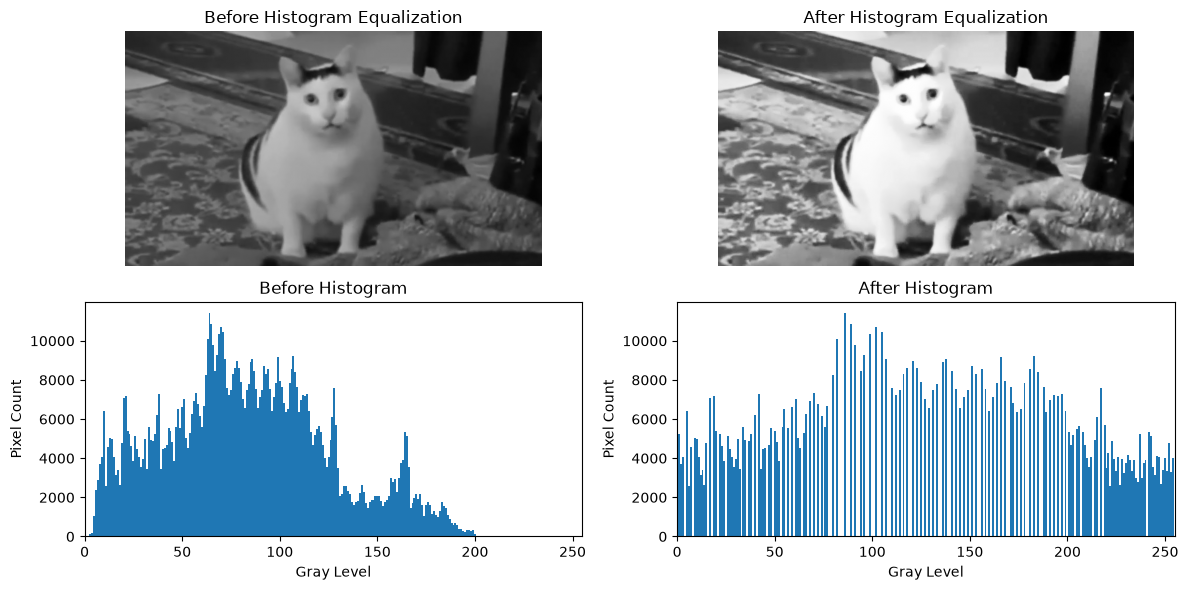

In [4]:
%matplotlib inline
from Codes.Quiz2 import *

show_histogram_equalization(
    "Data/Quiz2.jpg"
)

由上圖可見:

1. 處理前  
影像的對比度較低、背景昏暗不明；直方圖呈現right-skewed，在高灰階區（200~255）幾乎沒有像素分佈。

2. 處理後  
明暗對比顯著提升，背景黑白層次更分明，灰階分佈被拉伸並擴展到了完整的 0~255 區間 

### 進階
- 使用 NumPy 自行實作演算法，並與 OpenCV 提供的方法進行比較。  
- 重複執行 N = 50 次並取平均值，比較（1）執行速度、（2）影像增強效果、（３）兩種方法之間的差

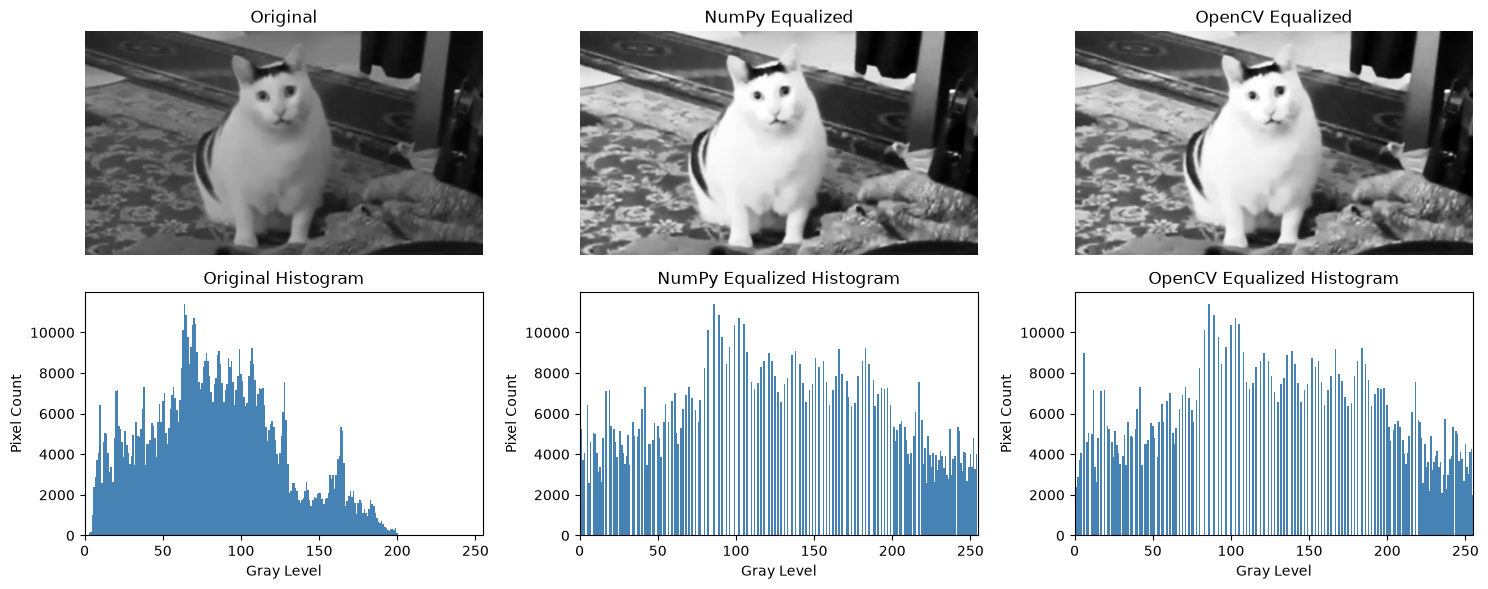

Quiz2 - Histogram Equalization (Data/Quiz2.jpg)
重複執行次數 N = 50
[執行速度]
  NumPy  平均執行時間: 12.6546 ms
  OpenCV 平均執行時間: 0.4593 ms
  速度比 (NumPy / OpenCV): 27.55x
[影像增強效果 (標準差 / 熵)]
  原始影像     : std=42.90, entropy=7.337
  NumPy 結果   : std=73.52, entropy=7.212
  OpenCV 結果  : std=73.58, entropy=7.198
[兩方法差異]
  最大像素差異  : 1
  平均像素差異  : 0.5500
  誤差 <=1 比例 : 100.00%
輸出圖檔: Data/Quiz2\Quiz2_result.png


In [ ]:
# Quiz 2
quiz2_result = run_quiz2(
    f"{image_path}/Quiz2.jpg",
    f"{image_path}/Quiz2_result",
    N = 50
)

#### 實驗結果

| 項目     |  原始影像 |      NumPy |    OpenCV |
| ------ | ----: | ---------: | --------: |
| 標準差    | 42.90 |      73.52 |     73.58 |
| 熵      | 7.337 |      7.212 |     7.198 |
| 平均執行時間 |     — | 12.8288 ms | 0.4291 ms |


#### Quiz2 小結
1. **對比度提升**：  
原始影像標準差為 42.90，經 NumPy Histogram Equalization 後增加至 73.52，OpenCV 則為 73.58。標準差反映灰階值的離散程度，增加代表灰階分布被拉開，明暗對比度獲得提升。

2. **Entropy 略降**：  
Entropy 由原始的 7.337 變為 NumPy 的 7.212 與 OpenCV 的 7.198。這說明 Histogram Equalization 的主要作用是重新分配灰階值、擴展動態範圍，並不代表 Entropy 必然增加——重新映射後部分灰階值的分布可能反而更集中。

3. **執行速度**：  
OpenCV（0.43 ms）約為 NumPy 實作（12.83 ms）的 30 倍。NumPy 版本需自行完成 Histogram 計算、CDF 累積、正規化與 LUT 映射等步驟，而 OpenCV 為針對影像處理最佳化的底層實作。

4. **結果一致性**：  
兩方法標準差非常接近，且最大像素差異僅 1、平均像素差異僅 0.55，100% 像素差異 ≤ 1，代表兩種實作幾乎得到相同的影像結果，差異主要來自四捨五入／整數轉換誤差。

---
## Quiz3
### 基礎:  
- 利用 Perspective Transformation 將斜拍影像校正為正視影像  


#### 流程

1. **Gaussian Blur**：灰階化後做高斯模糊，降低雜訊干擾
2. **Canny**：邊緣偵測，並以 dilate/erode 讓邊緣更連續
3. **輪廓偵測**：依面積排序所有輪廓，用 `approxPolyDP` 找出近似四邊形（4 個角點）且面積夠大的輪廓；若找不到則 fallback 為最大輪廓的最小外接矩形
4. **角點排序**：以四點中心為基準，依角度排序後對齊為 TL → TR → BR → BL
5. **Perspective Transform**：`getPerspectiveTransform` + `warpPerspective`，輸出正視影像

單張影像模式: Data/Quiz3/3-1.jpg


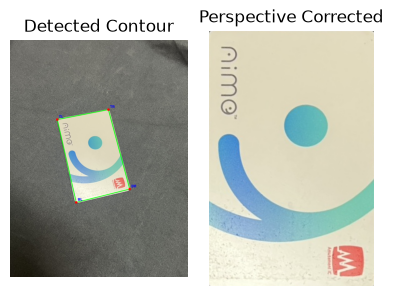

校正結果已儲存: Data/Quiz3_result\3-1-corrected.jpg


In [6]:
# 單張影像校正
%matplotlib inline
quiz3_batch_result = run_quiz3(
    f"{image_path}/Quiz3/3-1.jpg",
    f"{image_path}/Quiz3_result",
    show = True
)


### 進階:  
- 讓同一套流程可以針對多張影像自動完成梯形校正，  
- 探討不同拍攝角度下的校正效果，找出演算法開始無法正確校正的角度或條件，並說明可能原因  

由於手動拍照有過多不可控變因，故將測試圖像分兩部分進行:
#### A. data augmentation
首先使用 \Codes\utils\Quiz3_data_augmentation.py 生成不同條件之圖像，含:
1. 水平、垂直旋轉  
2. 明亮度
3. 對比  
4. 解析
5. 模糊
6. 雜訊

並且背景選擇全黑 (0, 0, 0)，預期得到理想數值。接著使用自動化對所有圖像進行梯形校正:

In [7]:
# 多張影像校正：演算法套用在資料夾內所有影像
# image_path 改傳資料夾路徑，即可自動化校正所有圖像
quiz3_batch_result = run_quiz3(
    f"{image_path}\Quiz3_aug",
    f"{image_path}\Quiz3_aug_result"
)

偵測到資料夾模式，共 25 張影像待處理
校正失敗: 無法在影像中偵測到四邊形輪廓: Data\Quiz3_aug\Quiz3_aug_contrast_0.2.jpg
校正失敗: 無法在影像中偵測到四邊形輪廓: Data\Quiz3_aug\Quiz3_aug_resolution_5percent.jpg
校正結果已儲存至: Data\Quiz3_aug_result


由以上輸出及輸出資料可得知，本演算法的極限為:
1. 對比值 $<= 0.2$ 
2. 解析度 $<= 5%$ 
3. 視角旋轉 $>= 85^\circ$ 

**失效原因說明：**
- **對比 ≤ 0.2 時失效**：  
Canny 邊緣偵測本質上是對灰階梯度大小設定門檻（`canny_low` / `canny_high`）進行篩選。當對比度被壓縮到極低，物體邊界與背景的灰階差異也大幅縮小，梯度強度普遍低於門檻值，導致邊緣點大量消失、輪廓無法閉合，`approxPolyDP` 自然無法近似出穩定的四頂點結果。

- **解析度 ≤ 5% 時失效**：  
影像大幅降採樣後，原本清銳的直線邊界會因混疊（aliasing）與平滑化而模糊、鋸齒化，角點座標精度也隨解析度下降而變粗。`approxPolyDP` 對邊界形狀變化非常敏感，低解析度下容易近似出非 4 頂點的形狀，導致篩選失敗。

- **視角旋轉 ≥ 85° 時失效**：  
與透視縮短（foreshortening）直接相關——視角趨近 90° 時，物體投影面積趨近於 0，四邊形面積低於篩選門檻，邊界形狀也高度退化。此數值高於一般實拍情境下的失效角度（通常 60°–75° 即開始不穩定），因為本實驗採用全黑背景排除了背景雜訊與陰影干擾，屬於理想條件下的理論上限；真實拍攝環境中光照不均、背景複雜度、鏡頭畸變等因素，會使實際可用角度範圍更保守。

#### B. 實拍圖片

In [8]:
quiz3_batch_result = run_quiz3(
    f"{image_path}\Quiz3",
    f"{image_path}\Quiz3_result"
)

偵測到資料夾模式，共 10 張影像待處理
校正結果已儲存至: Data\Quiz3_result


可從資料夾觀看校正結果，可見本演算法可實際應用於實拍圖像，並正確校正。

---
## Quiz4
### 基礎
- 將兩張具有重疊區域的影像，使用 SIFT 等特徵偵測與匹配方法完成影像拼接 

### 演算法原理
1. **SIFT 特徵偵測 (Scale-Invariant Feature Transform)**：透過建立 Difference of Gaussian (DoG) 在多個尺度空間中偵測極值點作為 keypoint，因此對影像的縮放、旋轉、部分光照變化具有不變性。每個關鍵點依其鄰域的梯度方向分佈計算出一個 128 維 descriptor，作為該特徵點的「指紋」。
   ```python
   sift = cv2.SIFT_create()
   kp, des = sift.detectAndCompute(gray, None)
   ```
2. **特徵匹配：FLANN + KNN + Ratio Test**：利用 FLANN 加速搜尋每個描述子在另一張影像中最相近的候選點，採用 KNN（k=2）找出兩個最相似的候選匹配，再套用 Lowe's ratio test（`m.distance < 0.75 * n.distance` 才視為可靠匹配），藉此濾除模糊、重複紋理造成的錯誤匹配。
3. **Homography 估計與 RANSAC**：兩張影像若可視為同一平面或拍攝中心不變的旋轉關係，其對應關係可用 3×3 投影轉換矩陣（Homography, H）描述。`cv2.findHomography(..., cv2.RANSAC, 5.0)` 反覆隨機取樣最小點集估計 H，並統計在容許誤差（5 pixel）內支持該 H 的 inliers 數量，選出內點最多的模型，有效排除誤匹配的干擾。
4. **影像扭曲與融合 (Warp & Blend)**：先計算影像1 四個角點經 H 轉換後的座標，與影像2 的角點座標取聯集邊界決定輸出畫布大小；用平移矩陣把座標平移到非負範圍後，分別將影像1（H 轉換）與影像2（純平移）warp 到同一張畫布；依兩張影像的有效像素遮罩分類重疊區域，並以像素值平均（各佔 0.5 權重）融合，避免拼接處出現明顯的亮度或色彩斷層。
5. **輸出**：`Quiz4-matches.jpg`（SIFT 特徵匹配預覽圖）、`Quiz4-result.jpg`（拼接結果影像）

SIFT 特徵點數量: img1=2683, img2=1523
良好匹配數量: 305, RANSAC 內點: 208
執行時間: 0.3237 秒


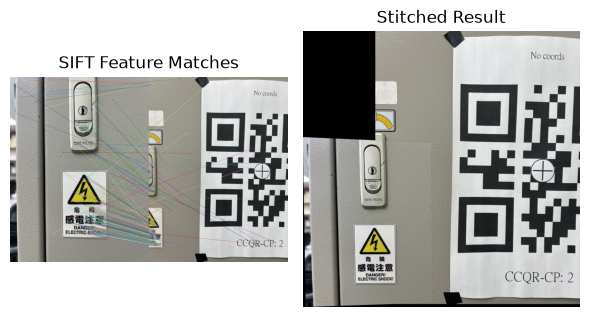

In [9]:
%matplotlib inline

quiz4_result = run_quiz4(
    f"{image_path}/Quiz4/4-1-L.jpg",
    f"{image_path}/Quiz4/4-1-R1.jpg",
    f"{image_path}/Quiz4_result",
    detail = True,
    preprocessing = None
)

### 進階-1

- 調整影像的亮度、拍攝角度或重疊範圍，觀察在不同條件下的拼接效果，找出演算法開始無法成功拼接的條件，並說明可能原因。
- 嘗試在影像拼接前加入適當的前處理方法，提升特徵偵測、匹配與拼接的穩定性。

### 4-1 重疊遞減

重疊圖片同上，為「感電注意」貼紙。依序將 4-3-R 圖片之貼紙裁切，留下比例為  
(1) 0.5  
(2) 0.25  
(3) 0.125  
(4) 貼紙中最右邊的文字驚嘆號  
(5) 僅剩貼紙白邊
由以下結果可得，(1)~(4)都有很好的拼接效果，而 (5) 可獲取之特徵過少，無法有效還原

4-1-R1


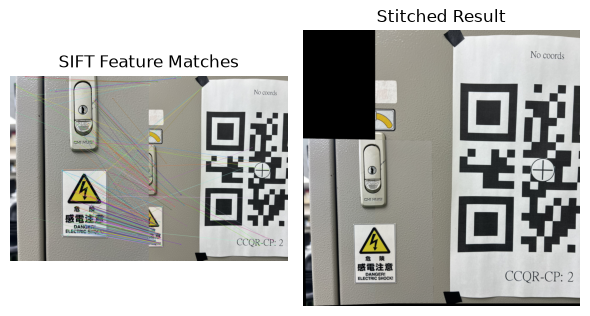

4-1-R2


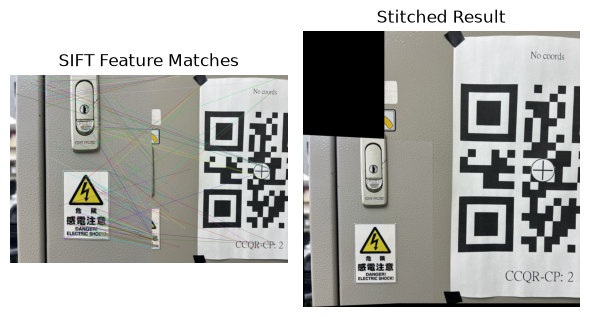

4-1-R3


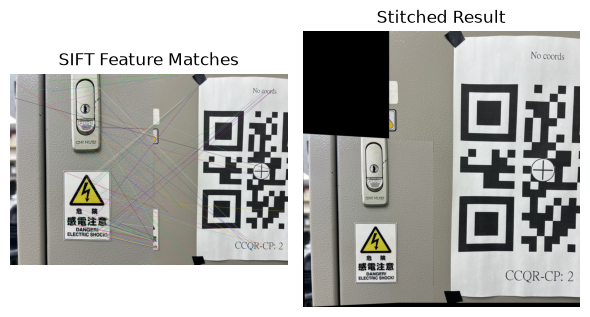

4-1-R4


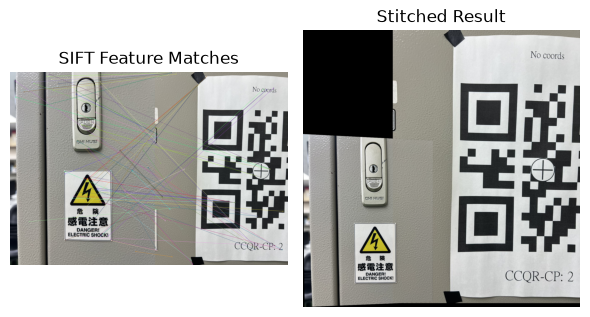

4-1-R5


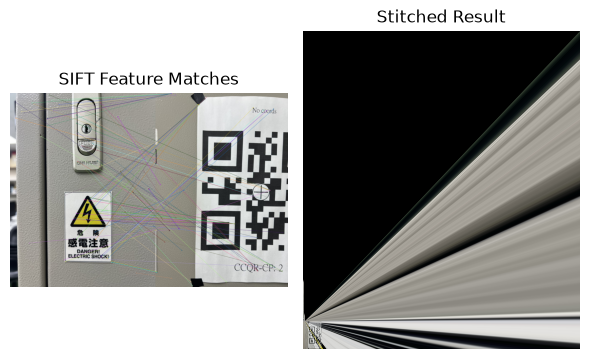

In [10]:
for i in range(5):
    print(f"4-1-R{i+1}")
    quiz4_result = run_quiz4(
        f"{image_path}/Quiz4/4-1-L.jpg",
        f"{image_path}/Quiz4/4-1-R{i+1}.jpg",
        f"{image_path}/Quiz4_result"
    )

### 4-2 影像亮度遞增遞減
延伸上圖，將右圖亮度遞減 25%, 50%, 75%, 100%。

**結論**：本演算法對亮度變化的穩健性相當高，測試範圍內的所有亮度條件皆能成功拼接。

**原因說明**：這與「亮度差異過大會導致匹配失敗」的直覺推測不完全相符，值得進一步說明——關鍵在於此處的亮度調整屬於整體乘性衰減（未造成飽和/裁切），而非局部過曝造成的資訊遺失：
- SIFT 的描述子在計算完成後會做正規化（normalization），本質上描述的是關鍵點鄰域內的相對梯度方向分佈，而非絕對亮度值。只要亮度調整是線性縮放且未讓像素值裁切到 0 或 255，關鍵點鄰域的相對梯度結構仍大致保留，因此 SIFT 對均勻調暗/調亮具有良好的不變性。
- 唯有當亮度調整造成大範圍像素飽和（例如過曝到全白、或過暗到全黑導致梯度資訊完全歸零）時，才會真正破壞局部紋理結構、造成匹配失敗——本次測試的調暗幅度尚未觸及大範圍裁切的臨界點。

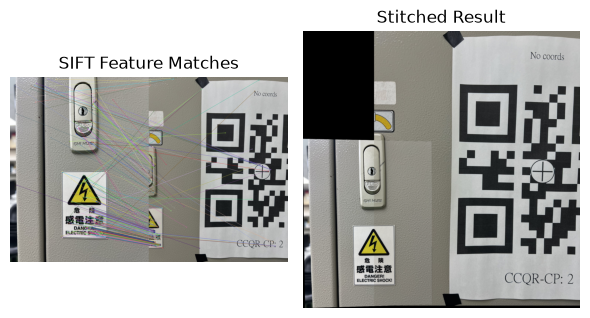

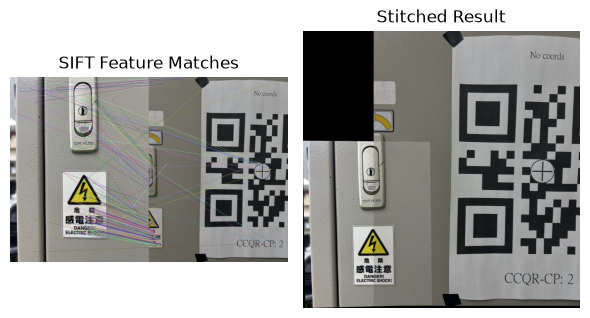

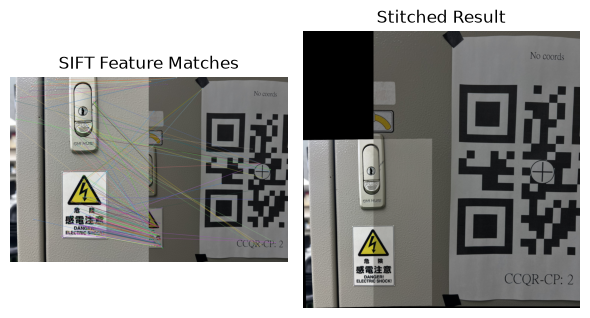

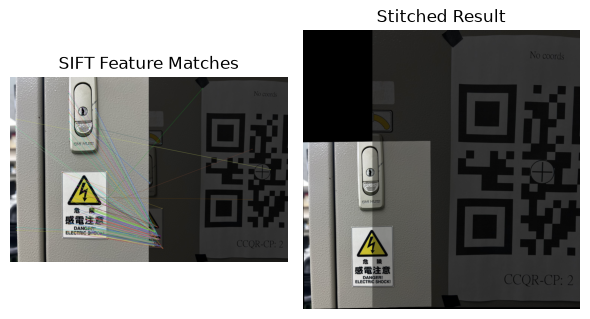

In [11]:
for i in range(4):
    
    quiz4_result = run_quiz4(
        f"{image_path}/Quiz4/4-2-L.jpg",
        f"{image_path}/Quiz4/4-2-R{i+1}.jpg",
        f"{image_path}/Quiz4_result"
    )

#### 4-3 角度變更
固定左圖，在盡量保留相同特徵前提下，右圖逐步增加拍攝角度。

**結論**：當兩張影像的視角相差接近 70° 時，開始無法順利拼接。

**原因說明**：
- SIFT 的不變性主要建立在平面內（in-plane）旋轉與縮放，對於視角改變造成的平面外旋轉（out-of-plane rotation，即透視形變），其穩健性有限。視角差距擴大時，同一物理特徵點在兩張影像中的局部外觀（patch）差異隨之增加，描述子距離上升，通過 ratio test 的匹配比例下降。
- 若拍攝場景並非完全平面（存在深度變化），角度差過大還會產生視差（parallax），使單一 Homography 矩陣無法同時準確描述畫面中所有對應點的幾何關係，RANSAC 篩選出的內點比例也會隨之降低，最終導致估計出的 H 誤差過大或匹配數不足以支撐穩定估計。
- 實測的 70° 臨界角與上述理論分析一致，可作為此類重疊拍攝情境下的實務參考上限。

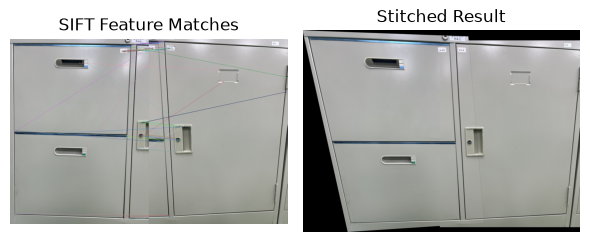

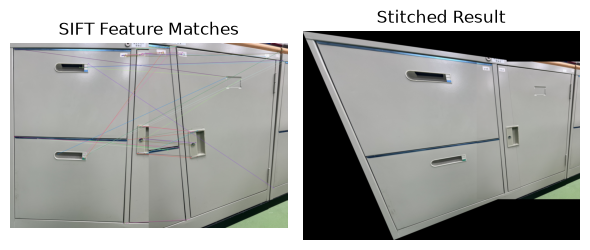

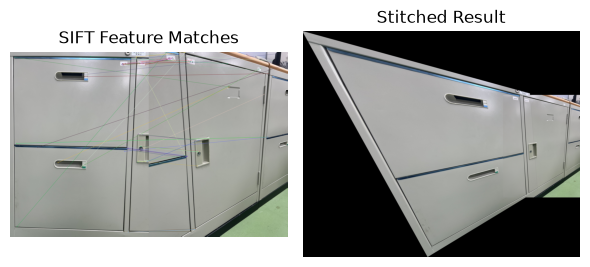

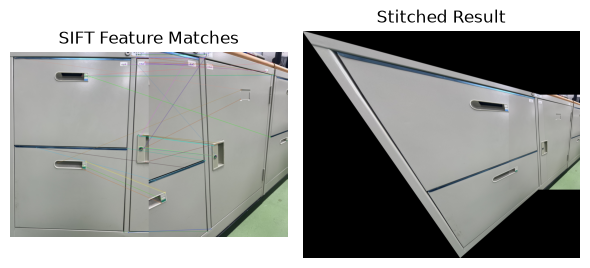

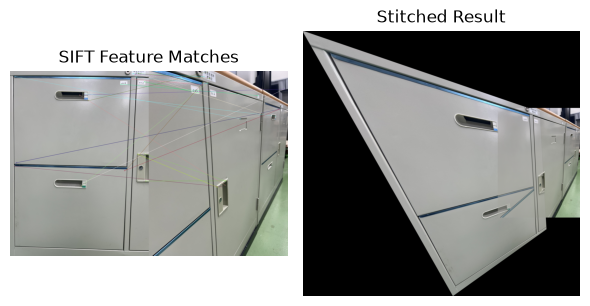

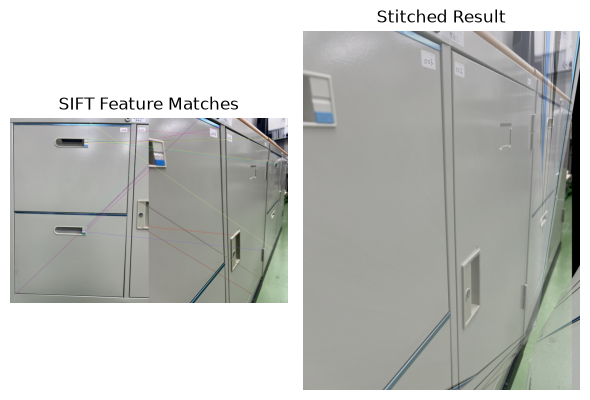

In [12]:
for i in range(6):
    
    quiz4_result = run_quiz4(
        f"{image_path}/Quiz4/4-3-L.jpg",
        f"{image_path}/Quiz4/4-3-R{i+1}.jpg",
        f"{image_path}/Quiz4_result"
    )

### 進階-2 加入前處理
- 嘗試在影像拼接前加入適當的前處理方法，提升特徵偵測、匹配與拼接的穩定性。

選擇重疊區域同時包含變電箱及天花板網格的影像進行測試，天花板網格具有大量規律且重複的區塊，屬於較容易產生相似局部紋理的區域，藉此比較加入前處理後對 SIFT 特徵偵測與匹配結果的影響。

| 條件 | img1 特徵點 | img2 特徵點 | 良好匹配 | RANSAC 內點 | 執行時間 |
| --- | ---: | ---: | ---: | ---: | ---: |
| 無前處理 | 176 | 189 | 15 | 8 | 0.5358 秒 |
| CLAHE | 1170 | 1230 | 54 | 31 | 0.4122 秒 |

**觀察：**
- **特徵點數量大幅增加**：  
加入 CLAHE 後，img1 特徵點由 176 增加至 1170，img2 由 189 增加至 1230，分別增加約 5.6 倍與 6.5 倍，表示 CLAHE 提升了影像局部對比度，使原本較不明顯的邊緣與紋理更容易被 SIFT 偵測。

- **良好匹配與 RANSAC 內點增加**：  
良好匹配由 15 組增加至 54 組（約 3.6 倍），RANSAC 內點由 8 個增加至 31 個（約 3.9 倍），Inlier Ratio 由 53.3% 提升至 57.4%，代表增加的匹配並非單純增加錯誤匹配，仍有較高比例通過幾何一致性檢驗。

- **執行時間**：  
由 0.5358 秒降至 0.4122 秒，但此差異不宜直接解釋為 CLAHE 能提升效率，可能受系統負載等因素影響，本實驗重點仍在特徵偵測與匹配品質。

無前處理
SIFT 特徵點數量: img1=176, img2=189
良好匹配數量: 15, RANSAC 內點: 8
執行時間: 0.3117 秒


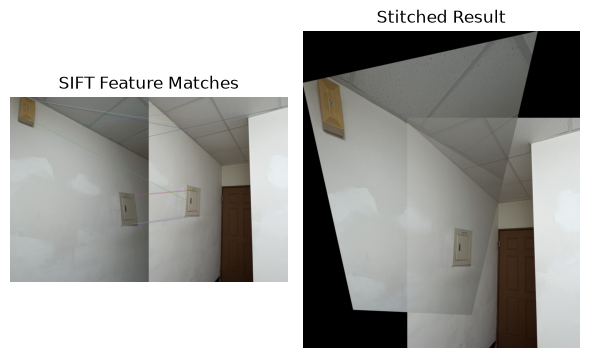

有前處理 (clahe)
前處理設定: {'denoise': False, 'clahe': True, 'sharpen': False, 'gray_equalize': False}
SIFT 特徵點數量: img1=1170, img2=1230
良好匹配數量: 55, RANSAC 內點: 31
執行時間: 0.4777 秒


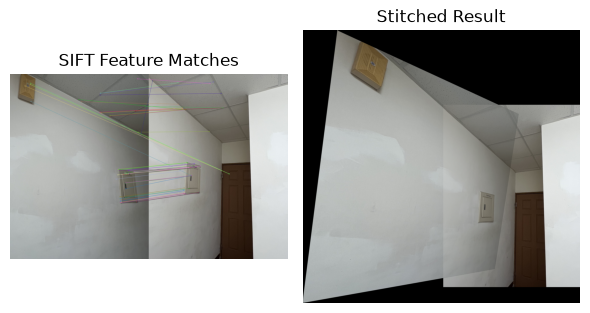

In [13]:
%matplotlib inline
print("無前處理")
quiz4_result = run_quiz4(
    f"{image_path}/Quiz4/4-4-L.jpg",
    f"{image_path}/Quiz4/4-4-R.jpg",
    f"{image_path}/Quiz4_result",
    detail = True
)
print("有前處理 (clahe)")
quiz4_result = run_quiz4(
    f"{image_path}/Quiz4/4-4-L.jpg",
    f"{image_path}/Quiz4/4-4-R.jpg",
    f"{image_path}/Quiz4_result",
    detail = True,
    preprocessing={"denoise": False, "clahe": True, "sharpen": False, "gray_equalize": False},
)

#### Quiz4進階小結
本次前處理僅啟用 CLAHE（Contrast Limited Adaptive Histogram Equalization），將影像分割成局部區域分別進行對比度增強，相較於全域直方圖等化更能強化局部亮暗差異，因而使 SIFT 偵測到更多關鍵點。不過天花板網格本身重複性高，單純增加特徵點不代表所有匹配都可靠，因此需搭配 RANSAC 內點數與 Inlier Ratio 判斷匹配的幾何一致性。  
結果顯示 CLAHE 對低對比或局部紋理不明顯的影像具有正面效果，有助於提升影像拼接的穩定性。